# Model: DeBERTa
Notebook ini melatih model Transformer berbasis `microsoft/deberta-v3-base` untuk Stance Classification FNC-1.

In [1]:
# Environment Configuration & Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import torch
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

ENVIRONMENT = "local" # or "kaggle"

if ENVIRONMENT == "kaggle":
    TRAIN_PATH = "/kaggle/input/datasets/deanfebrio/aol-textmining-fakenewsdetection-dataset/processed/train_processed.csv"
    TEST_PATH = "/kaggle/input/datasets/deanfebrio/aol-textmining-fakenewsdetection-dataset/processed/test_processed.csv"
    OUTPUT_DIR = "/kaggle/working/model-deberta/"
elif ENVIRONMENT == "local":
    TRAIN_PATH = "./data/processed/train_processed.csv"
    TEST_PATH = "./data/processed/test_processed.csv"
    OUTPUT_DIR = "./artifacts/model-deberta/"
else:
    raise ValueError(f"Unknown environment: {ENVIRONMENT}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Environment: {ENVIRONMENT}")
print(f"Train path: {TRAIN_PATH}")
print(f"Test path: {TEST_PATH}")
print(f"Output dir: {OUTPUT_DIR}")


Environment: local
Train path: ./data/processed/train_processed.csv
Test path: ./data/processed/test_processed.csv
Output dir: ./artifacts/model-deberta/


## Load Data & Group Split
Membagi dataset training dengan metode `GroupShuffleSplit` untuk memisahkan Validation Set berdasarkan `Body ID` (pencegahan data leakage).

In [2]:
# Load Data
print("Loading datasets...")
df_train_full = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print("Full Train Shape:", df_train_full.shape)
print("Test Shape:", df_test.shape)
print("\nLabel Distribution (Train):\n", df_train_full['Stance'].value_counts())
print("\nUnique Body IDs (Train):", df_train_full['Body ID'].nunique())

# Critical Requirement: Group Split by Body ID
# Mencegah overlap Body ID antara train dan validation (mencegah data leakage)
print("\nPerforming GroupShuffleSplit...")
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get the indices for train and validation
train_idx, val_idx = next(gss.split(df_train_full, groups=df_train_full['Body ID']))

df_train = df_train_full.iloc[train_idx].copy()
df_val = df_train_full.iloc[val_idx].copy()

print("Train Shape:", df_train.shape)
print("Val Shape:", df_val.shape)
print("Unique Body IDs (Train):", df_train['Body ID'].nunique())
print("Unique Body IDs (Val):", df_val['Body ID'].nunique())

# Explicitly check for overlap
train_bodies = set(df_train['Body ID'].unique())
val_bodies = set(df_val['Body ID'].unique())
overlap = train_bodies.intersection(val_bodies)
print(f"Overlap Body IDs between Train and Val: {len(overlap)}")
assert len(overlap) == 0, "DATA LEAKAGE DETECTED! Body IDs overlap."


Loading datasets...
Full Train Shape: (49972, 4)
Test Shape: (25413, 3)

Label Distribution (Train):
 Stance
unrelated    36545
discuss       8909
agree         3678
disagree       840
Name: count, dtype: int64

Unique Body IDs (Train): 1683

Performing GroupShuffleSplit...
Train Shape: (39587, 4)
Val Shape: (10385, 4)
Unique Body IDs (Train): 1346
Unique Body IDs (Val): 337
Overlap Body IDs between Train and Val: 0


## Label Encoding
Mengonversi kelas `Stance` menjadi angka dengan `LabelEncoder` dan menyimpan mapping kelasnya.

In [3]:
# Label Encoding
print("Encoding labels...")
le = LabelEncoder()

# Fit on train and transform
df_train['label'] = le.fit_transform(df_train['Stance'])
df_val['label'] = le.transform(df_val['Stance'])
if 'Stance' in df_test.columns:
    df_test['label'] = le.transform(df_test['Stance'])

# Mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_mapping)

# Save encoder
encoder_path = os.path.join(OUTPUT_DIR, 'label_encoder.pkl')
with open(encoder_path, 'wb') as f:
    pickle.dump(le, f)
print(f"Label encoder saved to {encoder_path}")


Encoding labels...
Label Mapping: {'agree': np.int64(0), 'disagree': np.int64(1), 'discuss': np.int64(2), 'unrelated': np.int64(3)}
Label encoder saved to ./artifacts/model-deberta/label_encoder.pkl


## Evaluation & Utility Functions
Fungsi-fungsi seragam yang diimplementasikan di semua notebook untuk mengkalkulasi matriks F1, menampilkan heatmap, dan mengekstrak *top error analysis*.

In [4]:
# Common Evaluation Functions
# F1 Macro digunakan sebagai metrik utama karena class imbalance.

def evaluate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    return {
        'accuracy': acc,
        'precision_macro': prec_macro,
        'recall_macro': rec_macro,
        'f1_macro': f1_macro,
        'precision_weighted': prec_weighted,
        'recall_weighted': rec_weighted,
        'f1_weighted': f1_weighted
    }

def plot_confusion_matrix(y_true, y_pred, classes, output_dir):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
    plt.show()

def get_error_analysis(df, y_true, y_pred, probs, classes, top_n=20):
    errors = []
    for i in range(len(y_true)):
        if y_true[i] != y_pred[i]:
            confidence = np.max(probs[i])
            errors.append({
                'Body ID': df.iloc[i].get('Body ID', ''),
                'Headline': df.iloc[i].get('Headline', ''),
                'Article Body': df.iloc[i].get('articleBody', '')[:200] + "...",
                'True Label': classes[y_true[i]],
                'Predicted Label': classes[y_pred[i]],
                'Confidence': confidence
            })
    
    df_errors = pd.DataFrame(errors)
    if not df_errors.empty:
        df_errors = df_errors.sort_values(by='Confidence', ascending=False).head(top_n)
    return df_errors


## Tokenization
Inisialisasi tokenizer HuggingFace khusus untuk model yang sedang dijalankan.

In [5]:
from transformers import AutoTokenizer

MODEL_NAME = "microsoft/deberta-v3-base"
print(f"Loading tokenizer: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Loading tokenizer: microsoft/deberta-v3-base


## Dataset Preparation
Membentuk Pytorch Dataset dan mengonversi `Headline` (Text A) dan `Article Body` (Text B) menggunakan *pair-sequence padding* (512 max length).

In [6]:
from torch.utils.data import Dataset

class FNC_Dataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length
        # Tokenizer secara otomatis akan menangani formasi pair sequence (Headline + Article Body)
        self.encodings = self.tokenizer(
            self.df['Headline'].tolist(),
            self.df['articleBody'].tolist(),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        self.labels = self.df['label'].tolist() if 'label' in self.df.columns else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

print("Tokenizing datasets...")
train_dataset = FNC_Dataset(df_train, tokenizer)
val_dataset = FNC_Dataset(df_val, tokenizer)


Tokenizing datasets...


## Class Imbalance Handling
Mengkalkulasi distribusi *class weights* dari frekuensi label kelas dan mengikatnya sebagai *Weighted Cross-Entropy Loss* untuk membantu konvergensi model pada sampel kelas minoritas.

In [7]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
from transformers import Trainer

print("Computing class weights...")
class_weights = compute_class_weight('balanced', classes=np.unique(df_train['label']), y=df_train['label'])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_weights_tensor = class_weights_tensor.to(device)
print("Class weights:", class_weights)

# Kustomisasi kelas Trainer untuk menambahkan Weighted Cross Entropy (penanganan Class Imbalance)
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


Computing class weights...
Class weights: [ 3.40797176 14.85998498  1.3633765   0.34413902]


## Model Training
Melakukan inisialisasi hiperparameter Transformer dan mengaktifkan *Early Stopping* berdasarkan optimalisasi parameter `f1_macro`.

In [8]:
import accelerate
import torch

print("=== DEVICE CHECK ===")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Device Capability: {torch.cuda.get_device_capability(0)}")
    print(f"Current Device Index: {torch.cuda.current_device()}")
else:
    print("WARNING: Running on CPU!")
print("====================")

from transformers import AutoModelForSequenceClassification, TrainingArguments, EarlyStoppingCallback

print("Loading model...")
num_labels = len(le.classes_)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels, use_safetensors=True)

# HF Compute Metrics
def compute_metrics_hf(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return evaluate_metrics(labels, preds)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    warmup_ratio=0.1,
    gradient_accumulation_steps=8,
    fp16=torch.cuda.is_available(),
    eval_strategy="epoch",  # For latest HF transformers version
    save_strategy="epoch",
    metric_for_best_model="f1_macro",
    load_best_model_at_end=True,
    logging_dir=os.path.join(OUTPUT_DIR, 'logs'),
    logging_steps=100
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_hf,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting training...")
trainer.train()


=== DEVICE CHECK ===
CUDA Available: True
Device Name: NVIDIA GeForce RTX 4060 Laptop GPU
Device Capability: (8, 9)
Current Device Index: 0
Loading model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.169500,0.472794,0.950602,0.805784,0.835295,0.818577,0.952666,0.950602,0.951375
2,0.057700,0.486376,0.965431,0.858179,0.875423,0.865102,0.966281,0.965431,0.965603
3,0.064900,0.577724,0.960616,0.833750,0.844313,0.838376,0.961360,0.960616,0.960835
4,0.001100,0.659227,0.963216,0.840994,0.854644,0.847546,0.963859,0.963216,0.963483


TrainOutput(global_step=9900, training_loss=0.12932481188590478, metrics={'train_runtime': 10372.1363, 'train_samples_per_second': 19.083, 'train_steps_per_second': 1.193, 'total_flos': 4.166460472624742e+16, 'train_loss': 0.12932481188590478, 'epoch': 4.0})

## Evaluation & Error Analysis
Evaluasi komprehensif, menampilkan *Confusion Matrix*, *F1 Macro*, dan mengurutkan 20 prediksi salah dengan *confidence* probabilitas tertinggi.

Evaluating on Validation Set...



Validation Metrics:
accuracy: 0.9654
precision_macro: 0.8582
recall_macro: 0.8754
f1_macro: 0.8651
precision_weighted: 0.9663
recall_weighted: 0.9654
f1_weighted: 0.9656

Classification Report:
              precision    recall  f1-score   support

       agree       0.88      0.81      0.84       774
    disagree       0.66      0.78      0.71       174
     discuss       0.89      0.92      0.91      1650
   unrelated       1.00      0.99      1.00      7787

    accuracy                           0.97     10385
   macro avg       0.86      0.88      0.87     10385
weighted avg       0.97      0.97      0.97     10385



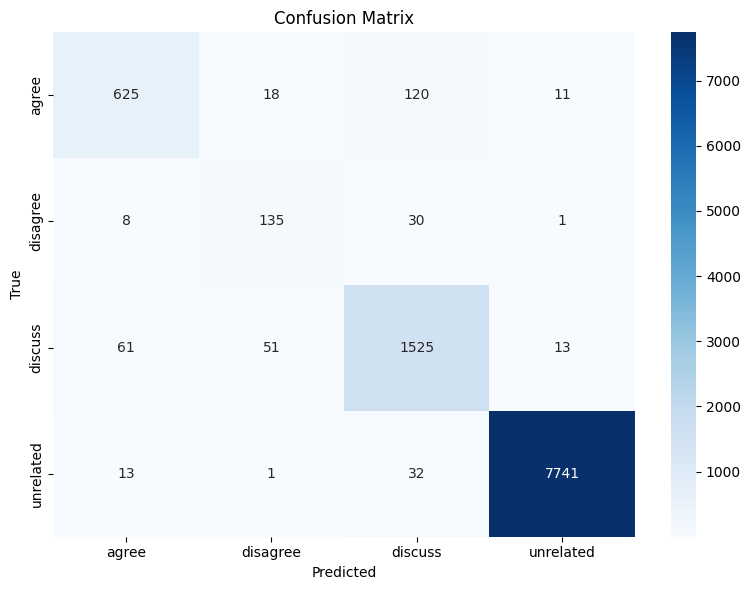


Top 20 Error Analysis (Highest Confidence):


,Body ID,Headline,Article Body,True Label,Predicted Label,Confidence
266,2206,Unverified video shows beheading of aid worker...,"A ""propaganda video"" released by ISIS has set ...",discuss,unrelated,0.999981
257,2206,Unconfirmed reports saying ISIS UK Hostage Dav...,"A ""propaganda video"" released by ISIS has set ...",discuss,unrelated,0.999980
260,2206,"Hostage David Haines' Murder 'Evil', PM Says","A ""propaganda video"" released by ISIS has set ...",agree,unrelated,0.999972
183,1806,"Lady on FB: I'm 41, Intersex, and Fucked Micha...",Michael Phelps may be off to rehab trying to f...,discuss,unrelated,0.999968
256,2206,British hostage David Haines beheaded by Islam...,"A ""propaganda video"" released by ISIS has set ...",agree,unrelated,0.999967
312,2284,The baby from Teletubbies reveals herself,At least now I know who to direct my sun rage ...,discuss,unrelated,0.999967
261,2206,ISIS Video Shows Execution of David Cawthorne ...,"A ""propaganda video"" released by ISIS has set ...",agree,unrelated,0.999966
265,2206,British aid worker David Haines beheaded by ISIL,"A ""propaganda video"" released by ISIS has set ...",agree,unrelated,0.999964
264,2206,"David Haines Beheaded By ISIS, Execution Video...","A ""propaganda video"" released by ISIS has set ...",agree,unrelated,0.999961
167,1683,Fake BBC News website set up to carry Charlie ...,The killing of the french policeman is also be...,disagree,unrelated,0.999954


In [9]:
# Predict and Evaluate on Validation Set
print("Evaluating on Validation Set...")
predictions = trainer.predict(val_dataset)
logits = predictions.predictions
preds = np.argmax(logits, axis=1)

# Probabilitas menggunakan logit -> softmax
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

metrics = evaluate_metrics(df_val['label'].values, preds)
print("\nValidation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# Save metrics
metrics_path = os.path.join(OUTPUT_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

# Classification Report
y_val = df_val['label'].values
target_names = [str(c) for c in le.classes_]
print("\nClassification Report:")
report = classification_report(y_val, preds, target_names=target_names)
print(report)

# Save Classification Report
df_report = pd.DataFrame(classification_report(y_val, preds, target_names=target_names, output_dict=True)).transpose()
df_report.to_csv(os.path.join(OUTPUT_DIR, 'classification_report.csv'))

# Plot and save Confusion Matrix
plot_confusion_matrix(y_val, preds, target_names, OUTPUT_DIR)

# Error Analysis
print("\nTop 20 Error Analysis (Highest Confidence):")
df_errors = get_error_analysis(df_val, y_val, preds, probs, le.classes_, top_n=20)
display(df_errors)

# Save predictions
df_val_preds = df_val.copy()
df_val_preds['predicted_label'] = preds
df_val_preds['confidence'] = np.max(probs, axis=1)
df_val_preds.to_csv(os.path.join(OUTPUT_DIR, 'predictions_validation.csv'), index=False)


## Save Artifacts
Menyimpan status akhir model setelah *Early Stopping*.

In [10]:
# Save Tokenizer and Model
print("Saving model and tokenizer...")
tokenizer_path = os.path.join(OUTPUT_DIR, 'tokenizer')
model_path = os.path.join(OUTPUT_DIR, 'model')

tokenizer.save_pretrained(tokenizer_path)
model.save_pretrained(model_path)

print(f"Tokenizer saved to {tokenizer_path}")
print(f"Model saved to {model_path}")


Saving model and tokenizer...
Tokenizer saved to ./artifacts/model-deberta/tokenizer
Model saved to ./artifacts/model-deberta/model
